In [3]:
import matplotlib.pyplot as plt 
import numpy as np 
import pandas as pd
import itertools

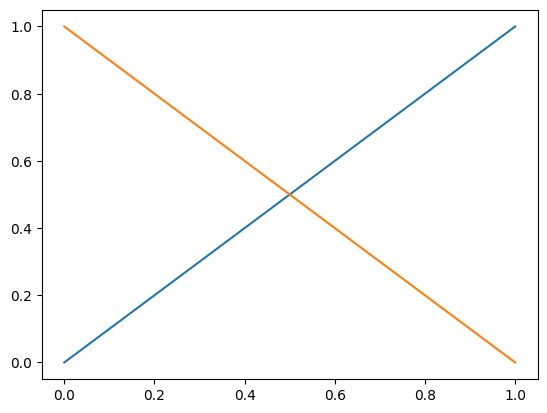

In [4]:
x = np.linspace(0,1,100)
plt.plot(x, x)
plt.plot(x, 1-x)

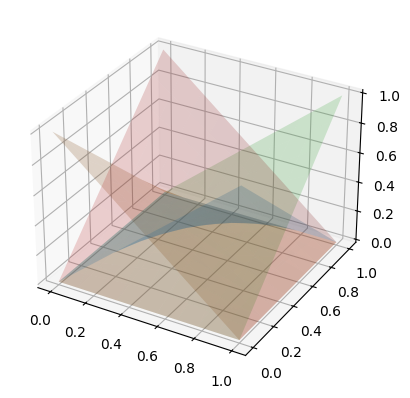

In [5]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
x = np.linspace(0,1,10)
X,Y=np.meshgrid(x,x)
ax.plot_surface(X,Y,X*(1-Y),alpha=0.2)
ax.plot_surface(X,Y,(1-X)*(1-Y),alpha=0.2)
ax.plot_surface(X,Y,X*Y,alpha=0.2)
ax.plot_surface(X,Y,(1-X)*Y,alpha=0.2)

In [11]:
class LinearShapeFunction():
    
    def __init__(self,dim=2,):
        self.dim = dim
        
    def N(self, xi):
        # xi: -1 to 1
        N = []
        for i in range(self.dim):
            N.append([0.5*(1+xi[i]),0.5*(1-xi[i])])
        N = list(itertools.product(*N))
        for i in range(len(N)):
            N[i] = np.array(N[i]).prod()
        return np.array(N).reshape(1,-1)    
    
    def B(self, xi):
        B = []
        for i in range(self.dim):
            Bi = []
            for j in reversed(range(self.dim)):
                if i == j:
                    Bi.append([xi[i]*0+1,xi[i]*0-1])
                else:
                    Bi.append([xi[i],1-xi[i]])
            Bi = list(itertools.product(*Bi))
            for j in range(len(Bi)):
                Bi[j] = np.array(Bi[j]).prod()
            B.append(Bi)
        B = np.array(B)
        print(B)
        print(B.shape)
        return B

In [18]:
dim = 1
shape1d = LinearShapeFunction(dim)
# x = np.linspace([0,0],[1,1],10)
x = np.linspace(-1,1,10).reshape(-1,1)
print(x.shape)

ss = [[] for _ in range(2**dim)]
print(ss)
print(x.shape)
for xi in x:
    s = shape1d.N(xi)
    print(s.shape)
    print('xi',xi)
    print('s', s[0])
    print('ss',ss)
    print('s shape', s.shape)
    
    print(len(ss), len(s))
    for i in range(2**dim):
        print(len(ss[i]))
        print('i',i)
        print('si',s[i])
        print('ssi',ss[i])
        ss[i].append(s[i])
        
ss = np.array(ss)
print(ss.shape)

plt.plot(x, ss[0])
plt.plot(x, ss[1])

(10, 1)
[[], []]
(10, 1)
(1, 2)
xi [-1.]
s [0. 1.]
ss [[], []]
s shape (1, 2)
2 1
0
i 0
si [0. 1.]
ssi []
0
i 1


IndexError: index 1 is out of bounds for axis 0 with size 1

In [ ]:
N.calc(np.array([[0.5,0.5]]))

array([0.5, 0.5, 0.5, 0.5])

In [ ]:
LinearShapeFunction(3).vertices

array([[0, 0, 0],
       [0, 0, 1],
       [0, 1, 0],
       [0, 1, 1],
       [1, 0, 0],
       [1, 0, 1],
       [1, 1, 0],
       [1, 1, 1]])

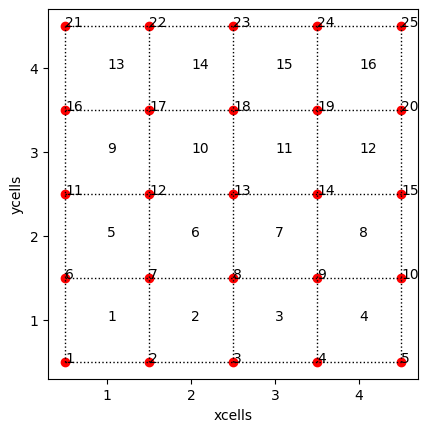

In [ ]:
ncellx = 4
ncelly = 4
nnodex=ncellx+1
nnodey=ncelly+1

xnodes, dx = np.linspace(0,1,ncellx+1,retstep=True)
ynodes, dy = np.linspace(0,1,ncelly+1,retstep=True)

nlocalnodes = 4
nlocalnodex = 2 
nlocalnodey = 2 
localnodeid = lambda i,j : i*nlocalnodex + j
localnodeij = lambda localnodeid : (localnodeid%nlocalnodex, localnodeid//nlocalnodex)

ncells = ncellx*ncelly
nnodes = (1+ncellx)*(1+ncelly)

cellid = lambda i, j: i*ncellx + j
cellij = lambda cellid : (cellid % ncellx, cellid // ncellx)
nodeid = lambda i, j : i*(ncellx+1) + j 
nodeij = lambda nodeid : (nodeid % nnodex, nodeid // nnodex)


XN,YN = np.meshgrid(xnodes,ynodes,indexing='xy')
plt.plot(XN,YN,color='k',linewidth=1,linestyle=':')
plt.plot(XN.T,YN.T,color='k',linewidth=1,linestyle=':')
plt.scatter(XN,YN,color='r',label='Nodes')
plt.gca().set_aspect('equal')
plt.xticks(xnodes[:-1]+0.5*dx, np.arange(1,ncellx+1))
plt.yticks(ynodes[:-1]+0.5*dx, np.arange(1,ncelly+1))
plt.xlabel('xcells')
plt.ylabel('ycells')


for cellid in range(ncells):
    i, j = cellij(cellid)
    plt.text((i+0.5)*dx, (j+0.5)*dy, str(cellid+1),)
    
for nodeid in range(nnodes):
    i, j = nodeij(nodeid)
    plt.text((i)*dx, (j)*dy, str(nodeid+1))
    


In [ ]:
#Determine the global nodes for each cell
nodemapping = np.zeros((ncells,nlocalnodes))
for cellid in range(ncells):
    celli, cellj = cellij(cellid)
    globalnode1 = cellj*nnodex + celli
    for localnodeid in range(nlocalnodes):
        localnodei, localnodej = localnodeij(localnodeid)
        globalnodeid = globalnode1 + localnodei + localnodej*nnodex
        nodemapping[cellid][localnodeid] = globalnodeid

In [ ]:
nodemapping

array([[ 0.,  1.,  6.,  7.],
       [ 1.,  2.,  7.,  8.],
       [ 2.,  3.,  8.,  9.],
       [ 3.,  4.,  9., 10.],
       [ 4.,  5., 10., 11.],
       [ 6.,  7., 12., 13.],
       [ 7.,  8., 13., 14.],
       [ 8.,  9., 14., 15.],
       [ 9., 10., 15., 16.],
       [10., 11., 16., 17.],
       [12., 13., 18., 19.],
       [13., 14., 19., 20.],
       [14., 15., 20., 21.],
       [15., 16., 21., 22.],
       [16., 17., 22., 23.],
       [18., 19., 24., 25.],
       [19., 20., 25., 26.],
       [20., 21., 26., 27.],
       [21., 22., 27., 28.],
       [22., 23., 28., 29.]])

# Initialize Grid
# For tk = 0 to tk = tf 
# Reset grid
# Map Particles to Grid Nodes
# Update Nodal Momenta
# Fix nodes with essential BCs
# Update particles from grid nodes
# Advance time

